In [16]:
from itertools import combinations
from math import prod, comb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp, gmean

In [17]:
#07-May-26, Noor Natour
df=pd.read_csv("feature_probs.csv")
df_obs=pd.read_csv('observed_counts.csv')
feature_probs={row["feature"]: row["count"]/row["total"] for _, row in df.iterrows()}
n_neurons_all=df["total"].iloc[0]

In [18]:
#07-May-26
def probability_k_features(k, probs_dict, n_neurons):
  features=list(probs_dict.keys())
  total_prob=0
  for active_neurons in combinations(features, k):
    p=1
    for f in features: #goes feature by feature and multiplies probabilities
      if f in active_neurons:
        p*=probs_dict[f] #multiply by the probability that this feature is active
      else:
        p*=(1-probs_dict[f]) ##multiply by the probability that this feature is inactive
    total_prob+=p #adds together all combinations that contain exactly k active features
  expected_neurons=n_neurons*total_prob
  return total_prob, expected_neurons

#the function computes the total probability that a neuron encodes exactly k feature

def binom_pmf(n, k, p):
    return comb(n, k)*(p**k)*((1-p)**(n-k))
def binom_right_tail(n, k_obs, p):
    total=0.0
    for k in range(k_obs, n+1):
        total+=binom_pmf(n, k, p)
    return total


In [19]:
# 07-May-26, calculated the probability of k features active in all neurons
for k in range (0, len(feature_probs)+1): #for k in range 0-5
  p_k, expected=probability_k_features(k, feature_probs, n_neurons_all)
  print(f"Probability of {k} features active: {p_k:.4f}, expected neurons ={expected:.2f}")

Probability of 0 features active: 0.1516, expected neurons =45.93
Probability of 1 features active: 0.3557, expected neurons =107.78
Probability of 2 features active: 0.3206, expected neurons =97.15
Probability of 3 features active: 0.1399, expected neurons =42.39
Probability of 4 features active: 0.0297, expected neurons =9.00
Probability of 5 features active: 0.0025, expected neurons =0.75


In [20]:
#07-May-26, verified that the total probability sums to 1
total=sum(probability_k_features(k, feature_probs, n_neurons_all)[0]
          for k in range(0, len(feature_probs)+1))
print(f"Total probability: {total:.2f}")

Total probability: 1.00


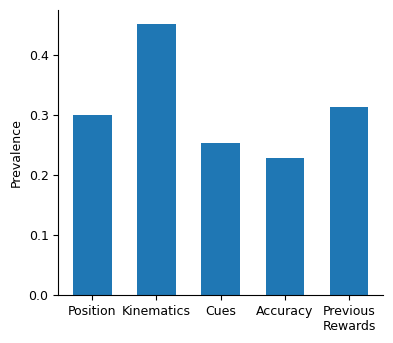

In [21]:
#09-May-26, added prevalence figure

feature_names=[name.title().replace(" ", "\n") for name in df["feature"]]
prevalence=(df["count"]/df['total']).tolist()
plt.figure(figsize=(4, 3.5))
plt.rcParams.update({'font.size':9,'font.family': 'DejaVu Sans'})
plt.bar(feature_names, prevalence, width=0.6)
plt.ylabel("Prevalence")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("feature_prevalence.tiff", dpi=600, bbox_inches='tight')
plt.show()

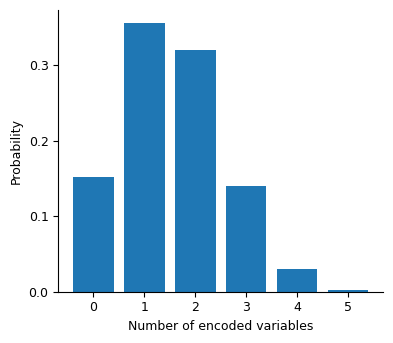

In [22]:
#09-May-26, added probability figure

k_probability_values=[]
probabilities=[]

for k in range(0, len(feature_probs)+1):
    p_k, expected = probability_k_features(k, feature_probs, n_neurons=303)

    k_probability_values.append(k)
    probabilities.append(p_k)

plt.figure(figsize=(4,3.5))

plt.bar(k_probability_values, probabilities)
plt.rcParams.update({'font.size': 9, 'font.family': 'DejaVu Sans'})
plt.xlabel("Number of encoded variables")
plt.ylabel("Probability")
plt.xticks(k_probability_values)
plt.yticks(np.arange(0, 0.37, 0.1))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("num_encoded_var.tiff", dpi=600, bbox_inches='tight')
plt.show()

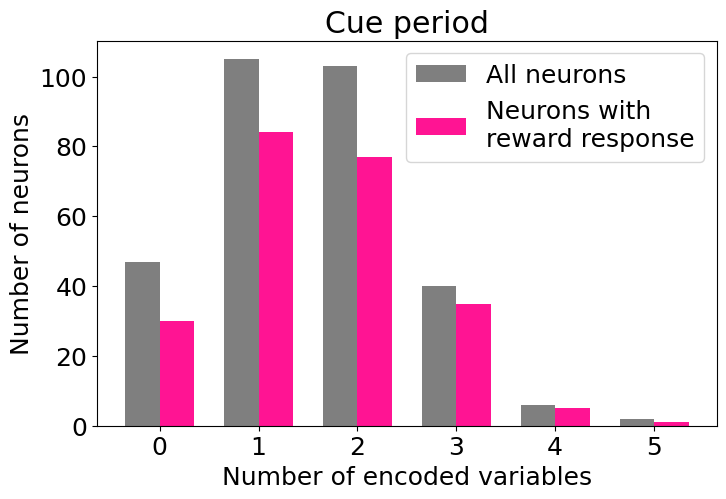

In [23]:
#07-May-26, reproduced Fig. 3b from Engelhard et al., 2019.

k_observed_values=df_obs["k"].tolist()
observed_cue=df_obs["all_neurons"].tolist()
observed_reward=df_obs['reward_response'].tolist()

x=np.arange(len(k_observed_values))
width=0.35

plt.figure(figsize=(8,5))
plt.rcParams.update({'font.size': 18})

plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
plt.title("Cue period")
plt.bar(x-width/2, observed_cue, width,color='tab:gray', label="All neurons")
plt.bar(x+width/2, observed_reward, width, color='deeppink', label="Neurons with\nreward response")
plt.xticks(x, k_observed_values)
plt.legend()

plt.show()

In [24]:
#07-May-26, calculated the observed and expected distributions
#for all cue-period neurons (n=303)
observed_counts_all=dict(zip(df_obs["k"], df_obs["all_neurons"]))
observed_values_all=[]
expected_values_all=[]
p_values_all=[]

print(f"{'k':<3} {'observed':<10} {'expected':<10} {'p(x>=obs)'}")

for k in observed_counts_all:
    p, expected=probability_k_features(k, feature_probs, n_neurons=n_neurons_all)
    observed=observed_counts_all[k]
    tail_prob = binom_right_tail(n_neurons_all, observed, p)

    observed_values_all.append(observed)
    expected_values_all.append(expected)
    p_values_all.append(tail_prob)

    print(f"{k:<3} {observed:<10} {expected:<10.2f} {tail_prob:<12.4f}")

#10-May-26, added Kolmogorov-Smirnov test

def enumerate_discrete(values, counts):
  enumerated=[]
  for value, count in zip(values, counts):
    enumerated.extend([int(value)]*int(count))
  return enumerated

observed_distribution_all=enumerate_discrete(observed_counts_all.keys(), observed_counts_all.values())
expected_distribution_all=enumerate_discrete(observed_counts_all.keys(), np.round(expected_values_all))

ks_statistic_all, ks_p_value_all=ks_2samp(observed_distribution_all, expected_distribution_all, alternative='two-sided')

#15-May-26, added geometric mean
geo_mean_all = gmean(p_values_all)

print(f"\nGeometric mean: {geo_mean_all:.4f}")

print("\nTwo-sample Kolmogorov-Smirnov test:")
print(f"KS statistic = {ks_statistic_all:.4f}")
print(f"p-value = {ks_p_value_all:.4f}")

k   observed   expected   p(x>=obs)
0   47         45.93      0.4561      
1   105        107.78     0.6513      
2   103        97.15      0.2538      
3   40         42.39      0.6785      
4   6          9.00       0.8880      
5   2          0.75       0.1720      

Geometric mean: 0.4455

Two-sample Kolmogorov-Smirnov test:
KS statistic = 0.0132
p-value = 1.0000


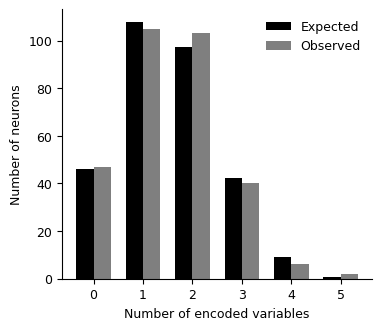

In [25]:
#07-May-26, generated "number of encoded variables to all neurons" figure
k_values=list(observed_counts_all.keys())
observed_all_neurons=list(observed_counts_all.values())
expected_all_neurons=[]
for k in k_values:
  p, expected=probability_k_features(k, feature_probs, n_neurons=n_neurons_all)
  expected_all_neurons.append(expected)

x=np.arange(len(k_values))
width=0.35
plt.rcParams.update({'font.size': 9,'font.family': 'DejaVu Sans'})
plt.figure(figsize=(4, 3.5))
plt.bar(x-width/2, expected_all_neurons, width, color='k', label="Expected")
plt.bar(x+width/2, observed_all_neurons, width, color='tab:gray', label="Observed")
plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(x, k_values)
plt.legend(frameon=False)
plt.savefig("all_neurons_Ex_Ob.tiff", dpi=600, bbox_inches='tight')
plt.show()


In [26]:
#07-May-26, calculated the probability of k features active in reward-responsive neurons
n_neurons_reward=df_obs["reward_response"].sum()
for k in range (len(feature_probs)+1):
  p_k, expected=probability_k_features(k, feature_probs, n_neurons=n_neurons_reward)
  print(f"Probability of {k} features active: {p_k:.6f}, expected neurons ={expected:.2f}")

Probability of 0 features active: 0.151572, expected neurons =35.16
Probability of 1 features active: 0.355717, expected neurons =82.53
Probability of 2 features active: 0.320630, expected neurons =74.39
Probability of 3 features active: 0.139910, expected neurons =32.46
Probability of 4 features active: 0.029707, expected neurons =6.89
Probability of 5 features active: 0.002464, expected neurons =0.57


In [27]:
#07-May-26, calculated the observed and expected distributions
# for reward-responsive cue-period neurons (n=232)

observed_counts_reward=dict(zip(df_obs['k'], df_obs['reward_response']))
n_neurons_reward=sum(observed_counts_reward.values())

observed_values_reward=[]
expected_values_reward=[]
p_values_reward=[]
rows_reward=[]

for k in observed_counts_reward:
    p, expected= probability_k_features(k, feature_probs, n_neurons=n_neurons_reward)
    observed=observed_counts_reward[k]

    tail_prob=binom_right_tail(n_neurons_reward, observed, p)

    rows_reward.append({"k": k, "Observed": observed, "Expected": round(expected, 2), "p(x>=obs)": round(tail_prob, 4)})
    observed_values_reward.append(observed)
    expected_values_reward.append(expected)
    p_values_reward.append(tail_prob)

df_reward=pd.DataFrame(rows_reward)
print(df_reward.to_string(index=False))


#10-May-26, added Kolmogorov-Smirnov test

observed_distribution_reward=enumerate_discrete(observed_counts_reward.keys(), observed_counts_reward.values())
expected_distribution_reward=enumerate_discrete(observed_counts_reward.keys(), np.round(expected_values_reward))

ks_statistic_reward, ks_p_value_reward=ks_2samp(observed_distribution_reward, expected_distribution_reward, alternative='two-sided')

#15-May-26, added geometric mean
geo_mean_reward=gmean(p_values_reward)
print(f"Geometric mean: {geo_mean_reward:.4f}")

print("\nTwo-sample Kolmogorov-Smirnov test:")
print(f"KS statistic = {ks_statistic_reward:.4f}")
print(f"p-value = {ks_p_value_reward:.4f}")

 k  Observed  Expected  p(x>=obs)
 0        30     35.16     0.8507
 1        84     82.53     0.4443
 2        77     74.39     0.3802
 3        35     32.46     0.3426
 4         5      6.89     0.8211
 5         1      0.57     0.4358
Geometric mean: 0.5101

Two-sample Kolmogorov-Smirnov test:
KS statistic = 0.0216
p-value = 1.0000


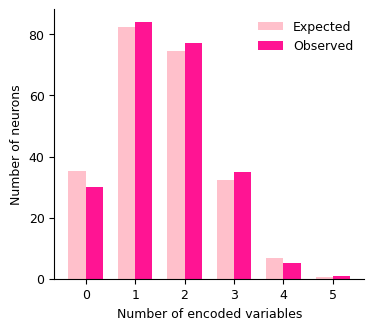

In [28]:
#07-May-26, generated "number of encoded variables to the reward responsive subset" figure

observed_reward_response=list(observed_counts_reward.values())
expected_reward_response=[]
for k in k_values:
  p, expected=probability_k_features(k, feature_probs, n_neurons=n_neurons_reward)
  expected_reward_response.append(expected)

plt.rcParams.update({'font.size':9,'font.family': 'DejaVu Sans'})
plt.figure(figsize=(4,3.5))
plt.bar(x-width/2, expected_reward_response, width, color='pink', label="Expected")
plt.bar(x+width/2, observed_reward_response, width, color='deeppink', label="Observed")
plt.xlabel("Number of encoded variables")
plt.ylabel("Number of neurons")
plt.xticks(x, k_values)
plt.yticks(np.arange(0, max(observed_reward_response), 20))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(frameon=False)
plt.savefig("reward_responsive_Ex_Ob.tiff", dpi=600, bbox_inches='tight')
plt.show()